In [12]:
import os

import numpy as np

import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt

APS_FONT_SIZE = 9   # pt, matches the two-column manuscript body text
plt.rcParams.update({
    'font.size': APS_FONT_SIZE,
    'axes.titlesize': APS_FONT_SIZE,
    'axes.labelsize': APS_FONT_SIZE,
    'xtick.labelsize': APS_FONT_SIZE,
    'ytick.labelsize': APS_FONT_SIZE,
    'legend.fontsize': APS_FONT_SIZE,
    'figure.titlesize': APS_FONT_SIZE,
})

QUANTUM_MAX = (np.sqrt(2) - 1) / 16   # quantum maximum of the wagon-wheel functional
CLASSICAL_BOUND = 0                    # classical bound of the wagon-wheel inequality

FOLDER_MAXENT = "Simulacion_01"
FOLDER_SCHMIDT = "Simulacion_02"
FOLDER_WERNER = "Simulacion_03"

FIG_DIR = "Figuras_Comparison"
os.makedirs(FIG_DIR, exist_ok=True)

## Figura 1 — Sim01_04: comparación de algoritmos según $N_{\rm sh}$

**Datos de origen:** `Simulacion_01/Sim01_04_N1e{3,4,5,6}.npz` (estado
máximamente entrelazado, `Out_mix`/`Out_sh` provenientes del bloque de
optimización guiada por Shadows; véase la Simulación 01_04 en
`Shadow_Simulations_Results.ipynb` para la descripción completa).

Dos subgráficos, ambos usando el ciclo de colores por defecto de
Matplotlib (`C0`-`C3`) para identificar $N_{\rm sh}$, la misma
convención empleada a lo largo de `Shadow_Simulations_Results.ipynb`:

- **Izquierda — Mediana Shadow, todos los $N_{\rm sh}$ juntos:** la
  evaluación Full Shadow (tanto el gradiente como el funcional
  estimados mediante Classical Shadows) para cada
  $N_{\rm sh}\in\{10^3,10^4,10^5,10^6\}$.
- **Derecha — Mediana Mix, todos los $N_{\rm sh}$ juntos:** la
  evaluación Shadow-Exact (gradiente estimado mediante Shadows,
  evaluación exacta de la trayectoria) para los mismos cuatro valores
  de $N_{\rm sh}$.

Comparar ambos subgráficos permite aislar qué parte de la brecha
residual respecto al máximo cuántico proviene de la estimación del
funcional en sí (Shadow, izquierda) frente a la estimación del
gradiente que guía la optimización (Mix, derecha).

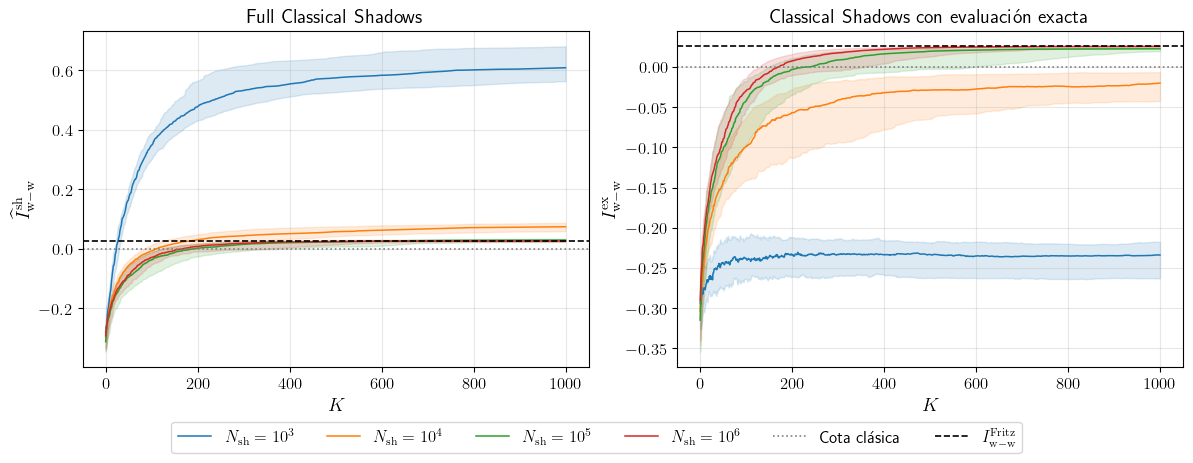

In [10]:
I_FRITZ = (np.sqrt(2) - 1) / 16

FS_TITLE = 14
FS_LABEL = 14
FS_TICKS = 12
FS_LEGEND = 12

N_SH_EXPONENTS = [3, 4, 5, 6]
DEFAULT_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]
NSH_COLORS = dict(zip(N_SH_EXPONENTS, DEFAULT_COLORS))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))

for exponent in N_SH_EXPONENTS:
    path = f"{FOLDER_MAXENT}/Sim01_04_N1e{exponent}.npz"
    Data = np.load(path)
    it = np.arange(len(Data["median_sh"]))

    ax1.plot(it, Data["median_sh"], color=NSH_COLORS[exponent], linewidth=1.1, label=rf"$N_{{\rm sh}}=10^{exponent}$")
    ax1.fill_between(it, Data["q1_sh"], Data["q3_sh"], color=NSH_COLORS[exponent], alpha=0.15)

ax1.axhline(CLASSICAL_BOUND, color="gray", linestyle=":", linewidth=1.2, label="Cota clásica")
ax1.axhline(I_FRITZ, color="black", linestyle="--", linewidth=1.2, label=r"$I_{\rm w-w}^{\rm Fritz}$")
ax1.set_xlabel(r"$K$", fontsize=FS_LABEL)
ax1.set_ylabel(r"$\widehat{I}_{\rm w-w}^{\rm sh}$", fontsize=FS_LABEL)
ax1.set_title("Full Classical Shadows", fontsize=FS_TITLE)
ax1.tick_params(axis="both", labelsize=FS_TICKS)
ax1.grid(alpha=0.3)

for exponent in N_SH_EXPONENTS:
    path = f"{FOLDER_MAXENT}/Sim01_04_N1e{exponent}.npz"
    Data = np.load(path)
    it = np.arange(len(Data["median_mix"]))

    ax2.plot(it, Data["median_mix"], color=NSH_COLORS[exponent], linewidth=1.1, label=rf"$N_{{\rm sh}}=10^{exponent}$")
    ax2.fill_between(it, Data["q1_mix"], Data["q3_mix"], color=NSH_COLORS[exponent], alpha=0.15)

ax2.axhline(CLASSICAL_BOUND, color="gray", linestyle=":", linewidth=1.2)
ax2.axhline(I_FRITZ, color="black", linestyle="--", linewidth=1.2)
ax2.set_xlabel(r"$K$", fontsize=FS_LABEL)
ax2.set_ylabel(r"$I_{\rm w-w}^{\rm ex}$", fontsize=FS_LABEL)
ax2.set_title("Classical Shadows con evaluación exacta", fontsize=FS_TITLE)
ax2.tick_params(axis="both", labelsize=FS_TICKS)
ax2.grid(alpha=0.3)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=6, bbox_to_anchor=(0.5, 0.03), frameon=True, fontsize=FS_LEGEND)

fig.tight_layout(rect=[0, 0.1, 1, 1])
fig.savefig(os.path.join(FIG_DIR, "Sim01_exacta_full.pdf"), bbox_inches="tight")

plt.show()

In [ ]:
A_VALUES = [0.30, 0.35, 0.40, 0.45, 0.50]
P_VALUES = [0.92, 0.94, 0.96, 0.98, 1.00]

# one shared qualitative palette across all curves in this figure, so no
# color is reused between the Schmidt and Werner subplots
ALL_COLORS = plt.cm.tab10(np.linspace(0, 1, len(A_VALUES) + len(P_VALUES)))
colors_a = ALL_COLORS[:len(A_VALUES)]
colors_p = ALL_COLORS[len(A_VALUES):]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.0, 3.2))

curves_schmidt = []
for a, color in zip(A_VALUES, colors_a):
    path = f"{FOLDER_SCHMIDT}/Sim02_03_02_a{a:.2f}_N1e6.npz"
    Data = np.load(path)
    median_sh = Data['median_sh']
    curves_schmidt.append(median_sh)
    it = np.arange(len(median_sh))
    ax1.plot(it, median_sh, color=color, linewidth=1.1, label=rf"$a={a:.2f}$")

ax1.axhline(CLASSICAL_BOUND, color='gray', linestyle=':', linewidth=1.2, )
ax1.axhline(QUANTUM_MAX, color='black', linestyle='--', linewidth=1.2, )
ax1.set_xlabel(r"$K$")
ax1.set_ylabel(r"$I_{\rm w-w}$")
ax1.set_title(r"Schmidt states")
ax1.grid(alpha=0.3)

curves_werner = []
for p, color in zip(P_VALUES, colors_p):
    path = f"{FOLDER_WERNER}/Sim03_03_02_p{p:.2f}_N1e6.npz"
    Data = np.load(path)
    median_sh = Data['median_sh']
    curves_werner.append(median_sh)
    it = np.arange(len(median_sh))
    ax2.plot(it, median_sh, color=color, linewidth=1.1, label=rf"$p={p:.2f}$")

ax2.axhline(CLASSICAL_BOUND, color='gray', linestyle=':', linewidth=1.2, label="Classical bound")
ax2.axhline(QUANTUM_MAX, color='black', linestyle='--', linewidth=1.2, label="Quantum maximum")
ax2.set_xlabel(r"$K$")
ax2.set_title(r"Werner states")
ax2.grid(alpha=0.3)

shared_ylim = compute_zoom_ylim(curves_schmidt + curves_werner)
ax1.set_ylim(shared_ylim)
ax2.set_ylim(shared_ylim)

# single shared legend outside the subplots, deduplicating the bound
# labels that both panels share (a and p entries are panel-specific)
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
combined = {}
for h, l in zip(handles1 + handles2, labels1 + labels2):
    combined.setdefault(l, h)
fig.legend(combined.values(), combined.keys(), loc='lower center', ncol=6,
           bbox_to_anchor=(0.51, 0.01), frameon=True )

fig.tight_layout(rect=[0, 0.12, 1, 0.93])
fig.savefig(os.path.join(FIG_DIR, "figure_2.pdf"), bbox_inches='tight')
plt.show()

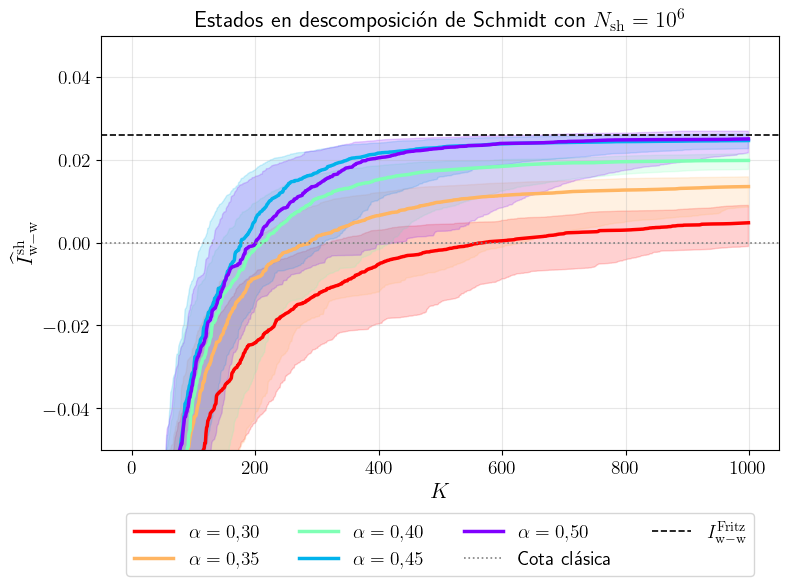

In [17]:
I_FRITZ = (np.sqrt(2) - 1) / 16

FS_TITLE = 16
FS_LABEL = 16
FS_TICKS = 14
FS_LEGEND = 14

A_VALUES = [0.30, 0.35, 0.40, 0.45, 0.50]
P_VALUES = [0.92, 0.94, 0.96, 0.98, 1.00]
#COLORS = plt.cm.tab10(np.linspace(0, 1, 5))
COLORS = plt.cm.rainbow_r(np.linspace(0, 1, 5))
# Estados en descomposición de Schmidt

fig_schmidt, ax_schmidt = plt.subplots(figsize=(8, 6))

for a, color in zip(A_VALUES, COLORS):
    path = f"{FOLDER_SCHMIDT}/Sim02_03_02_a{a:.2f}_N1e6.npz"
    Data = np.load(path)
    median_sh = Data["median_sh"]
    q1_sh = Data["q1_sh"]
    q3_sh = Data["q3_sh"]
    it = np.arange(len(median_sh))
    a_texto = f"{a:.2f}".replace(".", "{,}")
    ax_schmidt.plot(it, median_sh, color=color, linewidth=2.5, label=rf"$\alpha={a_texto}$")
    ax_schmidt.fill_between(it, q1_sh, q3_sh, color=color, alpha=0.18)


ax_schmidt.axhline(0, color="gray", linestyle=":", linewidth=1.2, label="Cota clásica")
ax_schmidt.axhline(I_FRITZ, color="black", linestyle="--", linewidth=1.2, label=r"$I_{\rm w-w}^{\rm Fritz}$")
ax_schmidt.set_xlabel(r"$K$", fontsize=FS_LABEL)
ax_schmidt.set_ylabel(r"$\widehat{I}_{\rm w-w}^{\rm sh}$", fontsize=FS_LABEL)
ax_schmidt.set_title(r"Estados en descomposición de Schmidt con $N_{\rm sh}=10^6$", fontsize=FS_TITLE)
ax_schmidt.tick_params(axis="both", labelsize=FS_TICKS)
ax_schmidt.grid(alpha=0.3)
ax_schmidt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=4, fontsize=FS_LEGEND)
ax_schmidt.set_ylim(-0.05, 0.05)

fig_schmidt.tight_layout()
fig_schmidt.savefig(os.path.join(FIG_DIR, "figure_2_schmidt.pdf"), bbox_inches="tight")
plt.show()


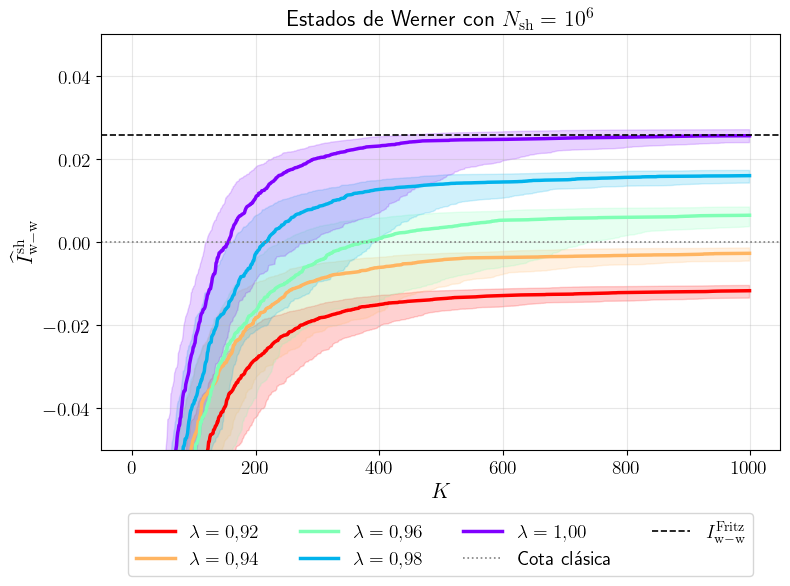

In [18]:
fig_werner, ax_werner = plt.subplots(figsize=(8, 6))
COLORS = plt.cm.rainbow_r(np.linspace(0, 1, 5))

for p, color in zip(P_VALUES, COLORS):
    path = f"{FOLDER_WERNER}/Sim03_03_02_p{p:.2f}_N1e6.npz"
    Data = np.load(path)
    median_sh = Data["median_sh"]
    q1_sh = Data["q1_sh"]
    q3_sh = Data["q3_sh"]
    it = np.arange(len(median_sh))
    p_texto = f"{p:.2f}".replace(".", "{,}")
    ax_werner.plot(it, median_sh, color=color, linewidth=2.5, label=rf"$\lambda={p_texto}$")
    ax_werner.fill_between(it, q1_sh, q3_sh, color=color, alpha=0.18)


ax_werner.set_ylim(-0.05, 0.05)
ax_werner.axhline(0, color="gray", linestyle=":", linewidth=1.2, label="Cota clásica")
ax_werner.axhline(I_FRITZ, color="black", linestyle="--", linewidth=1.2, label=r"$I_{\rm w-w}^{\rm Fritz}$")
ax_werner.set_xlabel(r"$K$", fontsize=FS_LABEL)
ax_werner.set_ylabel(r"$\widehat{I}_{\rm w-w}^{\rm sh}$", fontsize=FS_LABEL)
ax_werner.set_title(r"Estados de Werner con $N_{\rm sh}=10^6$", fontsize=FS_TITLE)
ax_werner.tick_params(axis="both", labelsize=FS_TICKS)
ax_werner.grid(alpha=0.3)
ax_werner.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=4, fontsize=FS_LEGEND)

fig_werner.tight_layout()
fig_werner.savefig(os.path.join(FIG_DIR, "figure_2_werner.pdf"), bbox_inches="tight")
plt.show()